In [41]:
# 绘制特征值
def PlotAccEuler(seg_type,event_df, i, Acc_df, Euler_df, excel_fname):
    # 构建3轴加速度
    import matplotlib.pyplot as plt
    import plotly 
    import numpy as np
    import plotly.graph_objects as go 
    from scipy.signal import find_peaks

    # 查找 Y 轴欧拉角的加速度峰值
    foot_x = seg_type + " Foot x"
    foot_y = seg_type + " Foot y"
    foot_z = seg_type + " Foot z"
    if seg_type == "Right":
        seg_type_cn = "右脚"
    else:
        seg_type_cn = "左脚"
    seg_type_event_list = [f'{seg_type_cn}离地', f'{seg_type_cn}着地',
                           f'{seg_type_cn}离地.1',f'{seg_type_cn}着地.1', 
                           f'{seg_type_cn}离地.2', f'{seg_type_cn}着地.2',
                           f'{seg_type_cn}离地.3', f'{seg_type_cn}着地.3', 
                           f'{seg_type_cn}离地.4', f'{seg_type_cn}着地.4']
    peaks,peak_heights = find_peaks(Euler_df[foot_y], height=5)
    plt.plot(peaks, peak_heights["peak_heights"], "o")
    plt.plot(Euler_df[foot_y].index, Euler_df[foot_y])
    print(peaks)


    #计算合加速度
    result_acc = np.sqrt(np.square(Acc_df[foot_x]) + np.square(Acc_df[foot_y]) + np.square(Acc_df[foot_z]))
    result_acc_two_axis = np.sqrt(np.square(Acc_df[foot_x]) + np.square(Acc_df[foot_y]))

    # 定义每个系列的数据
    s1 = go.Scatter(x=Acc_df[foot_x].index,
                    y=Acc_df[foot_x],
                    name = f"{seg_type_cn}自由加速度 x",
                    line=dict(color="#dd6046")) 
    s2 = go.Scatter(x=Acc_df[foot_y].index,
                    y=Acc_df[foot_y],
                    name = f"{seg_type_cn}自由加速度 y",
                    line=dict(color="#5cc99a"))  
    s3 = go.Scatter(x=Acc_df[foot_z].index,
                    y=Acc_df[foot_z],
                    name = f"{seg_type_cn}自由加速度 z",
                    line=dict(color="#656ef2"))

    s4 = go.Scatter(x=Euler_df[foot_x].index,
                    y=Euler_df[foot_x],
                    name = f"{seg_type_cn}欧拉角 x",
                    line=dict(color="red"))
    s5 = go.Scatter(x=Euler_df[foot_y].index,
                    y=Euler_df[foot_y],
                    name = f"{seg_type_cn}欧拉角 y",
                    line=dict(color="green"))
    s6 = go.Scatter(x=Euler_df[foot_z].index,
                    y=Euler_df["Right Foot z"],
                    name = f"{seg_type_cn}欧拉角 z",
                    line=dict(color="blue"))
    s7 = go.Scatter(x=result_acc_two_axis.index,
                    y=result_acc_two_axis,
                    name="合加速度",
                    line=dict(color="purple"))
    s8 = go.Scatter(x=peaks,
                    y=peak_heights["peak_heights"],
                    mode = "markers",
                    name="欧拉角Y峰值",
                    line=dict(color="midnightblue"))

    # 创建并显示图形
    fig = go.Figure(data=[s1,s2,s3,s4,s5,s6,s7,s8])
    fig.update_layout(title=excel_fname) # 设置图形标题

    for event in seg_type_event_list:
        if "着地" in event:
            line_color = "#dd6046" # 红色
            line_dash = "solid" # 实线
        elif "离地" in event:
            line_color = "#656ef2" #蓝色
            line_dash = "dash" # 虚线
        x = event_df.loc[i,event]
        fig.add_shape(
            x0 = x,
            y0 = 0,
            x1 = x,
            y1 = 1,
            yref="paper", #相对于画布的高度
            line = dict(
                color = line_color,
                width = 0.5,
                dash = line_dash, # 点划线
            )  
        )

    fig.show()

In [42]:
def GetAccEuler(excel_dir, excel_fname):
    import pandas as pd 
    import numpy as np 
    import os
    excel_path = os.path.join(excel_dir, excel_fname)
    Acc_df = pd.read_excel(excel_path, sheet_name = "Sensor Free Acceleration")
    Euler_df = pd.read_excel(excel_path, sheet_name = "Segment Orientation - Euler")
    return Acc_df, Euler_df

In [43]:
import pandas as pd 
import numpy as np 
import os

In [44]:
event_dir = "/Users/wangshuaibo/我的资料库/1项目/项目进行时/北京悦动/脑卒中项目/阿帅笔记/测试数据及分析结果/HarbinStroke/Xsens/Process_Data/着地离地特征时刻"
event_fname = "20240102_着地时刻离地时刻关键帧_吴雨伦.xlsx"
event_path = os.path.join(event_dir, event_fname)
excel_dir = "/Users/wangshuaibo/我的资料库/1项目/项目进行时/北京悦动/脑卒中项目/阿帅笔记/测试数据及分析结果/HarbinStroke/Xsens/Process_Data/Excel"
event_df = pd.read_excel(event_path, sheet_name = 0)
event_df

,文件夹名,备注,跺脚,跺脚类型,左脚离地,左脚着地,右脚离地,右脚着地,左脚离地.1,左脚着地.1,...,右脚离地.5,右脚着地.5,左脚离地.6,左脚着地.6,右脚离地.6,右脚着地.6,左脚离地.7,左脚着地.7,右脚离地.7,右脚着地.7
0,20230716_杜金良_Xsens_赤足-1.mvn,右脚离地不明显,469.0,左脚,Nan,Nan,639,688.0,774.0,799.0,...,1679.0,1776.0,1836.0,1870.0,1890.0,1982.0,2054.0,2073.0,NaN,NaN
1,20230716_杜金良_Xsens_穿鞋无绷带-1.mvn,右脚离地拖布,271.0,左脚,474,500,586,643.0,719.0,748.0,...,1777.0,1853.0,1913.0,1942.0,2011.0,2053.0,NaN,NaN,NaN,NaN
2,20230716_任友山_Xsens_赤足-1.mvn,离地时刻不在波峰,395.0,左脚,674,694,740,780.0,820.0,843.0,...,1377.0,1420.0,1450.0,1478.0,1514.0,1562.0,1596.0,1624.0,1668.0,1722.0
3,20230716_任友山_Xsens_穿鞋无绷带-1.mvn,NaN,413.0,左脚,601,618,658,699.0,727.0,759.0,...,1320.0,1357.0,1385.0,1415.0,1451.0,1500.0,1534.0,1559.0,1600.0,1642.0
4,20230722_沈文广_Xsens_赤足-1.mvn,NaN,937.0,右脚,1048,1081,1127,1195.0,1273.0,1314.0,...,2116.0,2173.0,2232.0,2266.0,2302.0,2355.0,2409.0,2450.0,2484.0,2539.0
5,20230722_沈文广_Xsens_穿鞋无绷带-1.mvn,NaN,1995.0,左脚,2144,2172,2216,2284.0,2364.0,2413.0,...,3352.0,3410.0,3468.0,3499.0,3549.0,3614.0,3682.0,3725.0,3767.0,3831.0
6,20230722_刘刚_Xsens_赤足-1.mvn,离地时刻没有明显的波形特征,947.0,右脚,1070,1100,1163,1221.0,1270.0,1312.0,...,1416.0,1475.0,1520.0,1566.0,1623.0,1691.0,1736.0,1784.0,1848.0,1898.0
7,20230722_刘刚_Xsens_穿鞋无绷带-1.mvn,NaN,586.0,右脚,756,790,846,889.0,930.0,967.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
event_df["文件夹名"]

0        20230716_杜金良_Xsens_赤足-1.mvn
1     20230716_杜金良_Xsens_穿鞋无绷带-1.mvn
2        20230716_任友山_Xsens_赤足-1.mvn
3     20230716_任友山_Xsens_穿鞋无绷带-1.mvn
4        20230722_沈文广_Xsens_赤足-1.mvn
5     20230722_沈文广_Xsens_穿鞋无绷带-1.mvn
6         20230722_刘刚_Xsens_赤足-1.mvn
7      20230722_刘刚_Xsens_穿鞋无绷带-1.mvn
8                                NaN
9                                NaN
10                               NaN
11                               NaN
12                               NaN
13                               NaN
Name: 文件夹名, dtype: object

[1056 1279 1470 1655 1856 2037 2233 2409 2606 2817 2995 3201 3581 3791
 3995 4179 4346 4526 4726 4931 5127 5359]


[ 918 1134 1198 1359 1410 1554 1743 1935 2122 2305 2491 2947 3119 3485
 3669 3724 3876 4073 4255 4429 4617 4800 5023 5220]


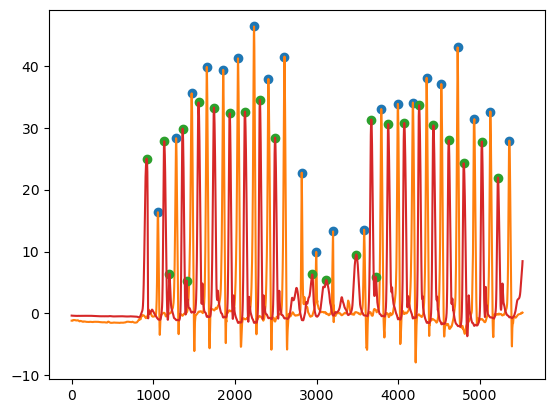

In [51]:
# 绘制图片
excel_fname = "20230722_沈文广_Xsens_赤足-1" + ".xlsx"
i = 4
seg_type = "Right"


Acc_df, Euler_df = GetAccEuler(excel_dir, excel_fname)
PlotAccEuler("Left",event_df, i, Acc_df, Euler_df, excel_fname)
PlotAccEuler("Right",event_df, i, Acc_df, Euler_df, excel_fname)

'Left Foot x'